Przygotowanie danych do regresji

In [1]:
SEED = 2137

import pandas as pd
import numpy as np

data = pd.read_csv("data/regresja/domy.csv")
data = pd.get_dummies(data, dtype=int)

y = data["SalePrice"]
X = data.drop("SalePrice", axis="columns")

Coś tam

In [2]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, accuracy_score

reg = linear_model.LinearRegression()
_ = reg.fit(X, y)

y_pred = reg.predict(X)
mean_squared_error(y, y_pred)

137125764.922724

In [3]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, accuracy_score

reg = linear_model.Ridge(alpha=.5)
_ = reg.fit(X, y)

y_pred = reg.predict(X)
mean_squared_error(y, y_pred)

188220532.7420818

Coś innego

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=SEED)
reg = linear_model.Ridge(alpha=.5)
_ = reg.fit(X_train, y_train)
print(reg.score(X_test, y_test))
y_pred_ridge = reg.predict(X_test)

reg = linear_model.LinearRegression()
_ = reg.fit(X_train, y_train)
print(reg.score(X_test, y_test))

y_pred_linear = reg.predict(X_test)

0.8953683113912312
0.8745355075941217


In [5]:
from random import random, randint
from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV

reg = linear_model.Ridge(alpha=1.0)
result = cross_validate(reg, X, y)
print(result["test_score"])
print(sum(result["test_score"]) / 5)

[0.88428597 0.81372312 0.8710612  0.85801879 0.68539988]
0.8224977940203008


In [6]:
from sklearn.model_selection import train_test_split, cross_validate

reg = linear_model.LinearRegression()
result = cross_validate(reg, X, y)
print(result["test_score"])
print(sum(result["test_score"]) / 5)

[0.79797612 0.73549614 0.81807141 0.75432311 0.60879268]
0.7429318918529767


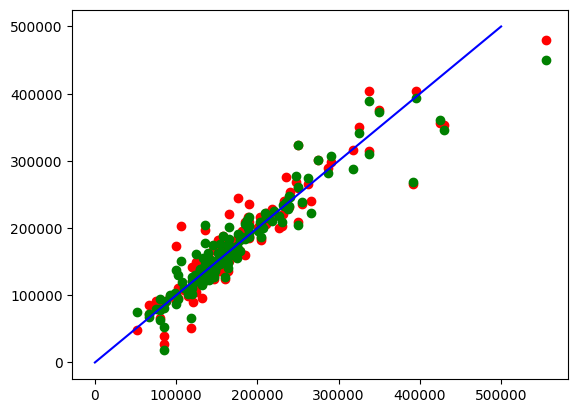

In [7]:
import matplotlib.pyplot as plt
plt.scatter(y_test, y_pred_linear, color="red")
plt.scatter(y_test, y_pred_ridge, color="green")

plt.plot([0, 500_000], [0, 500_000], color="blue")
plt.show()